<a href="https://colab.research.google.com/github/feronika-lab/Risk-Based-Motor-Insurance-Premium-Pricing-Engine-freMTPL2-with-Tweedie-and-XGBoost/blob/main/01_data_prep_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Loading & Understanding**

Memahami struktur data dan definisi variabel :

---

### 1. File: `freMTPL2freq.csv` (Data Polis & Risiko)

File ini adalah **tabel utama**. Setiap baris merepresentasikan satu periode polis asuransi untuk satu kendaraan.
* **Isi:** Informasi tentang tertanggung (nasabah) dan faktor risiko mereka.

### 2. File: `freMTPL2sev.csv` (Data Klaim & Kerugian)

File ini adalah **tabel transaksi**. File ini *hanya* mencatat kejadian klaim. Jika nasabah tidak pernah klaim, ID mereka **tidak ada** di file ini.
* **Isi:** Berapa besar uang yang harus dibayar asuransi untuk setiap kecelakaan.
---

### 3. Definisi Variabel

Berikut adalah penjelasan untuk istilah-istilah yang digunakan:

#### **A. IDpol (ID Polis)**
* **Definisi:** Nomor identitas polis asuransi.
* **Fungsi:** Ini adalah **penghubung** antara file `freq` dan `sev`.
* **Contoh:** Jika `IDpol` 12345 ada di kedua file, berarti nasabah nomor 12345 mengalami kecelakaan.

#### **B. Exposure (Durasi Risiko)**

* **Definisi:** Berapa lama (tahun) perusahaan asuransi menanggung risiko untuk polis tersebut.
* **Cara Baca:**
* `1.00`: Polis aktif penuh selama 1 tahun.
* `0.50`: Polis hanya aktif 6 bulan (misal nasabah membatalkan di tengah jalan atau baru bergabung).
* `0.08`: Polis baru aktif sebulan.

* **Kenapa Penting?**
* Nasabah A punya 1 klaim dalam 1 tahun (`Exposure` = 1.0).
* Nasabah B punya 1 klaim dalam 1 bulan (`Exposure` = 0.08).
* **Kesimpulan:** Nasabah B **jauh lebih berisiko** (ugal-ugalan) dibanding A, meskipun jumlah klaimnya sama-sama 1. Model yang akan dibuat harus menangkap ini.



#### **C. ClaimNb (Jumlah Klaim)**

* **Definisi:** Berapa kali nasabah mengajukan klaim *selama masa Exposure tersebut*.
* **Lokasi:** Ada di file `freq`.
* **Relasi:** Nilai ini harus konsisten dengan jumlah baris di file `sev`.
* Jika `ClaimNb` = 0: Tidak ada baris untuk ID ini di file `sev`.
* Jika `ClaimNb` = 2: Seharusnya ada 2 baris kejadian klaim untuk ID ini di file `sev`.



#### **D. ClaimAmount (Besar Kerugian)**

* **Definisi:** Jumlah uang (dalam Euro, karena **data Prancis**) yang dibayarkan asuransi untuk menutupi kerugian.
* **Lokasi:** Ada di file `sev`.
* **Sifat:** Distribusinya biasanya *heavy-tailed* (kebanyakan klaim nilainya kecil/sedang, tapi ada satu-dua klaim yang nilainya miliaran dan bisa memicu insolvensi perusahaan).
---

### 4. Relasi Antar Data (One-to-Many)

Hubungan antara `freq` dan `sev` adalah **One-to-Many** (Satu Polis bisa punya Banyak Klaim).

Gambaran :

* **Kasus 1: Polis tanpa klaim (No-claim policy) (Mayoritas)**
* Di `freq`: Ada datanya (Umur, Mobil, dll), `ClaimNb` = 0.
* Di `sev`: **Tidak ada data**.
* *Tindakan:* Saat di-join, `ClaimAmount` diisi 0.


* **Kasus 2: Polis dengan 1 klaim (Single-claim policy) (Klaim 1x)**
* Di `freq`: `ClaimNb` = 1.
* Di `sev`: misal Ada 1 baris dengan `ClaimAmount` = 2000 Euro.
* *Tindakan:* `ClaimAmount` digabungkan ke data polis.


* **Kasus 3: Polis dengan 2 klaim (Multiple-claim policy / Two-claim policy) (Klaim 2x)**
* Di `freq`: `ClaimNb` = 2.
* Di `sev`: Ada **2 baris** untuk ID yang sama.
* Baris 1: `ClaimAmount` = 500.
* Baris 2: `ClaimAmount` = 3000.


* *PENTING:* perlunya pengerjaan **menjumlahkan (sum)** dulu kedua angka `ClaimAmount` (500 + 3000 = 3500) sebelum digabungkan ke `freq`.



---

### 5. Cara Menggabungkan (Coding)
Langkah pengerjaan agar tidak terjadi duplikasi :

1. Ambil `freMTPL2sev`.
2. Lakukan `groupby('IDpol')` lalu `sum('ClaimAmount')`. (Sekarang 1 ID = 1 Baris Total Klaim).
3. Ambil `freMTPL2freq`.
4. Lakukan `left_join` ke data hasil langkah 2.
5. Isi `NaN` (yang tidak klaim) dengan 0.

```python
# Agregasi (seperti langkah 2)
df_sev_agg = df_sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()

# di-join ke tabel utama (seperti langkah 4)
df = df_freq.merge(df_sev_agg, on='IDpol', how='left')

```



In [ ]:
!pip -q install datasets pandas numpy



pada bagian ini ada beberapa tahap untuk mengeksplorasi isi data freq dan sev

In [ ]:
import pandas as pd
import numpy as np

# 1. Mendefinisikan URL Dataset
ds_freq_url = "https://huggingface.co/datasets/mabilton/fremtpl2/resolve/main/freMTPL2freq.csv"
ds_sev_url = "https://huggingface.co/datasets/mabilton/fremtpl2/resolve/main/freMTPL2sev.csv"

# 2. Loading Data
print("⏳ Memuat data dari server...")
df_freq = pd.read_csv(ds_freq_url)
df_sev = pd.read_csv(ds_sev_url)

# 3. Penghitungan Awal (Baris Raw)
row_freq = len(df_freq)
row_sev = len(df_sev)

# 4. Data Processing (Aggregation & Merging)
# Menjumlahkan ClaimAmount per IDpol di tabel severity
df_sev_agg = df_sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()

# Menggabungkan ke tabel frekuensi (Master)
df_final = df_freq.merge(df_sev_agg, on='IDpol', how='left')
df_final['ClaimAmount'] = df_final['ClaimAmount'].fillna(0)

# 5. Klasifikasi Data untuk Eksplorasi
total_idpol = len(df_final)

# Kategori A: Polis tanpa klaim (No-claim policy) (Tanpa Klaim)
count_zero = len(df_final[df_final['ClaimNb'] == 0])
pct_zero = (count_zero / total_idpol) * 100

# Kategori B: Phantom Claims (Klaim Ada di Freq tapi tidak ada nilai di Sev)
ids_pembayaran = set(df_sev['IDpol'].unique())
phantom_df = df_final[(df_final['ClaimNb'] >= 1) & (~df_final['IDpol'].isin(ids_pembayaran))]
count_phantom = len(phantom_df)
pct_phantom = (count_phantom / total_idpol) * 100

# Kategori C: True Claimants (Klaim Berbayar Nyata)
true_claimants = df_final[(df_final['ClaimNb'] >= 1) & (df_final['ClaimAmount'] > 0)]
count_true = len(true_claimants)
pct_true = (count_true / total_idpol) * 100

# 6. Menampilkan Laporan Ringkasan
print("\n" + "="*50)
print("📊 LAPORAN EKSPLORASI DATA (DATA UNDERSTANDING)")
print("="*50)
print(f"Total Baris Data Frekuensi (df_freq) : {row_freq:,}")
print(f"Total Baris Data Severity (df_sev)   : {row_sev:,}")
print("-" * 50)
print(f"Total Unik IDpol (Basis Polis)       : {total_idpol:,}")
print("-" * 50)
print(f"✅ 1. Zero Claims (Nasabah Aman)     : {count_zero:,} ({pct_zero:.2f}%)")
print(f"⚠️ 2. Phantom Claims (Tanpa Bayar)   : {count_phantom:,} ({pct_phantom:.2f}%)")
print(f"💰 3. True Claimants (Berbayar)      : {count_true:,} ({pct_true:.2f}%)")
print("="*50)

# 7. Menampilkan 10 Sampel Data Berbayar Nyata
print("\n📋 10 Contoh Data 'True Claimants' (Klaim Berbayar Nyata):")
cols_to_show = ['IDpol', 'ClaimNb', 'Exposure', 'ClaimAmount', 'DrivAge', 'VehPower']
# Menggunakan display() jika di Colab agar tampil sebagai tabel yang rapi
try:
    from google.colab import data_table
    display(true_claimants[cols_to_show].head(10))
except:
    print(true_claimants[cols_to_show].head(10).to_string(index=False))

⏳ Memuat data dari server...

📊 LAPORAN EKSPLORASI DATA (DATA UNDERSTANDING)
Total Baris Data Frekuensi (df_freq) : 678,013
Total Baris Data Severity (df_sev)   : 26,639
--------------------------------------------------
Total Unik IDpol (Basis Polis)       : 678,013
--------------------------------------------------
✅ 1. Zero Claims (Nasabah Aman)     : 643,953 (94.98%)
⚠️ 2. Phantom Claims (Tanpa Bayar)   : 9,116 (1.34%)
💰 3. True Claimants (Berbayar)      : 24,944 (3.68%)

📋 10 Contoh Data 'True Claimants' (Klaim Berbayar Nyata):


,IDpol,ClaimNb,Exposure,ClaimAmount,DrivAge,VehPower
66,139.0,1,0.75,303.00,61,7
93,190.0,1,0.14,1981.84,50,12
199,414.0,1,0.14,1456.55,36,4
205,424.0,2,0.62,10834.00,51,10
223,463.0,1,0.31,3986.67,45,5
287,606.0,1,0.84,1840.14,54,10
295,622.0,1,0.75,1397.97,34,5
388,811.0,1,0.76,971.98,44,5
396,830.0,1,0.68,1442.75,24,4
468,975.0,1,0.73,637.41,60,9


Penjelasan mengapa penggunaan Tweedie sangat krusial untuk data seperti `freMTPL2`: **(untuk penjelasan distribusinya lebih lanjut ada di file `02_glm_baseline_`

---

### 1. Karakteristik Data Asuransi (The "Zero-Inflation" Problem)

Data klaim asuransi memiliki bentuk yang sangat unik yang tidak bisa ditangani oleh regresi linear standar (OLS) atau Logistik biasa, karena:

* **Point Mass at Zero:** Sebagian besar data (sekitar 95-96%) bernilai nol karena nasabah tidak klaim.
* **Continuous Long Tail:** Sisanya adalah nilai klaim yang positif, terus-menerus, dan nilai klaim bisa sangat besar (ekstrem).

Jika menggunakan **RMSE (Mean Squared Error)**, model akan mencoba "menarik" garis rata-rata yang terlalu dipengaruhi oleh nilai nol, sehingga gagal memprediksi nilai klaim yang besar secara akurat.

---

### 2. Apa itu Distribusi Tweedie?

Secara teknis, Tweedie adalah bagian dari *Exponential Dispersion Model* (EDM). Kehebatannya terletak pada kemampuannya menggabungkan dua proses distribusi menjadi satu:

1. **Poisson Distribution:** Memodelkan seberapa sering kejadian terjadi (Frekuensi).
2. **Gamma Distribution:** Memodelkan seberapa besar kerugian jika kejadian terjadi (Severity).

Rumus varians pada distribusi Tweedie didefinisikan sebagai:
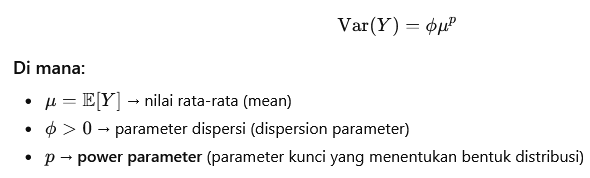



---

### 3. Mengapa  Sangat Spesial?

Parameter  menentukan jenis distribusi yang dihasilkan. Dalam kasus premi murni (*Pure Premium*), kita biasanya menggunakan nilai  di antara 1 dan 2 (1 <p <2) , seringkali sekitar **1.5**:

* Jika : Distribusi menjadi **Poisson**.
* Jika : Distribusi menjadi **Gamma**.
* **Jika :** Ini menjadi distribusi **Compound Poisson-Gamma**.

Sehingga pada distribusi ini secara otomatis menghitung probabilitas "apakah akan klaim?" sekaligus "berapa besar klaimnya?" dalam satu fungsi objektif tunggal.

---

### 4. Implementasi pada XGBoost & EBM

Saat menetapkan `objective='reg:tweedie'` pada XGBoost atau menggunakan EBM dengan Tweedie:

* **XGBoost:** Algoritma ini akan meminimalkan *Tweedie Deviance* alih-alih MSE. Ini memaksa model untuk lebih sensitif terhadap "sinyal" kecil di antara tumpukan nilai nol, sehingga hasil predisinya lebih realistis untuk premi asuransi.
* **EBM (Explainable Boosting Machine):** EBM akan membangun *shape functions* yang mengikuti logika Tweedie. Hasilnya, grafik pengaruh fitur (seperti usia pengemudi) tidak akan terlihat aneh karena terdistorsi oleh mayoritas nilai nol, melainkan akan menunjukkan risiko murni yang sebenarnya.

---

### 5. Keuntungan untuk Portofolio

* **Efisiensi:** Tidak perlu membuat dua model terpisah (satu untuk frekuensi, satu untuk severity). Cukup satu model Tweedie.
* **Akurasi Bisnis:** Premi yang dihasilkan lebih stabil dan tidak mudah terkena *overfitting* pada nilai klaim ekstrem (outliers).

> **Analogi Sederhana:** Menggunakan MSE pada data asuransi seperti mencoba mengukur curah hujan tahunan dengan penggaris biasa di gurun pasir yang jarang hujan—hasilnya akan selalu mendekati nol dan tidak berguna saat badai datang. Tweedie adalah alat ukur yang memang didesain untuk mendeteksi "kapan badai datang" dan "seberapa kuat badai tersebut".



In [ ]:
df_final.to_csv('df_final.csv', index=False)
print("Dataset df_final telah berhasil disimpan sebagai 'df_final.csv'")

Dataset df_final telah berhasil disimpan sebagai 'df_final.csv'


Mengapa ini penting untuk portofolio ?

  "Dataset ini menunjukkan ketidakseimbangan yang ekstrem (extreme class imbalance), di mana hanya 3,68% dari total polis yang menghasilkan klaim berbayar nyata (settled). Hal ini memvalidasi penggunaan model berbasis **Tweedie distribution** yang memang dirancang untuk menangani data asuransi dengan tumpukan nilai nol yang besar."

  Dalam proyek Premium Pricing Engine, angka 3,68% ini adalah tantangan teknis "Extreme Imbalance" atau "Sparsity".

  **Tantangan**: Model yang akan dibuat harus belajar dari data yang sangat sedikit (hanya 3,68% contoh "kejadian") untuk memprediksi risiko pada 96,32% nasabah lainnya.

  **Solusi**: Inilah alasan utama mengapa memilih Tweedie Loss Function pada XGBoost dan EBM. Tweedie sangat baik dalam menangani data di mana sebagian besar nilainya adalah nol, namun ada "long tail" (ekor panjang) pada nilai klaim yang dibayar.

# **Data Preparation & Feature Engineering**


Meskipun distribusi Tweedie adalah "mesin" yang hebat untuk menangani nilai nol (frekuensi) dan nilai positif (severity) secara sekaligus, mesin tersebut tetap membutuhkan **bahan bakar yang bersih** untuk bekerja maksimal.

Tweedie menangani masalah pada sisi **Target (Y)**, sedangkan Data Preparation & Feature Engineering menangani masalah pada sisi **Fitur/Input (X)**. Tanpa tahap ini, model Anda akan mengalami bias, *overfitting*, atau bahkan gagal melakukan proses *training*.

---

### Mengapa Tahap ini Tetap Wajib?

#### 1. Penanganan Outlier (Large Loss Handling)

Dalam asuransi, ada perbedaan antara "risiko normal" dan "bencana". Satu klaim bernilai 1 juta Euro (misal tabrakan beruntun) di tengah ribuan klaim rata-rata 500 Euro akan membuat model Tweedie menjadi tidak stabil / terpengaruh kuat oleh klaim ekstrem (high leverage) dan mencoba menaikkan premi semua orang secara tidak adil.

* **Tindakan:** Kita melakukan *Capping* atau *Winsorization*. Klaim ekstrem dipotong pada batas tertentu (misal ambil persentil 99,5%) agar model fokus pada pola risiko yang bisa diprediksi secara statistik.

#### 2. Mengubah Kategori menjadi Angka (Encoding)

Model ML (XGBoost/EBM) dan GLM tidak mengerti kata "Area A" atau "Brand B12". Mereka butuh angka.

* **One-Hot Encoding:** Bagus untuk fitur dengan kategori sedikit (seperti `VehGas`).
* **Target Encoding:** Bagus untuk fitur dengan banyak kategori (seperti `Region`) agar tidak menambah terlalu banyak kolom yang membuat model lambat.

#### 3. Memperbaiki Anomali Data `freMTPL2`

Dataset ini memiliki beberapa "bug" alami yang jika tidak di-cleaning akan merusak logika aktuaria:

* **Exposure > 1:** Secara hukum asuransi, periode observasi maksimal adalah 1 tahun (1.0). Data di atas itu harus dipotong (*clipping*).
* **Consistency Check:** Memastikan jika ada `ClaimAmount`, maka `ClaimNb` minimal harus 1.

---





In [ ]:

from sklearn.preprocessing import LabelEncoder

# --- 1. HANDLING OUTLIERS (Capping Severity) ---
# Kita potong ClaimAmount di persentil 99.5% untuk menstabilkan varians model
cap_val = df_final['ClaimAmount'].quantile(0.995)
df_final['ClaimAmount_Capped'] = df_final['ClaimAmount'].clip(upper=cap_val)

# --- 2. DATA CLEANING  ---
# Exposure tidak boleh lebih dari 1 tahun
df_final['Exposure'] = df_final['Exposure'].clip(upper=1.0)

# Menghapus data dengan Exposure yang tidak masuk akal (sangat mendekati 0)
df_final = df_final[df_final['Exposure'] > 0.001].copy()

# --- 3. FEATURE ENGINEERING ---
# Log Transform Density (Karena distribusinya sangat miring/skewed)
df_final['LogDensity'] = np.log(df_final['Density'])

# Binning Usia (Opsi: untuk GLM agar lebih stabil)
df_final['VehAge_Group'] = pd.cut(df_final['VehAge'], bins=[-1, 1, 5, 10, 100], labels=['New', 'Young', 'Mid', 'Old'])

# --- 4. ENCODING CATEGORICAL FEATURES ---
# Variabel Kategorikal yang akan kita pakai
cat_cols = ['Area', 'VehBrand', 'VehGas', 'Region', 'VehAge_Group']

# Menggunakan Label Encoding (untuk model berbasis Tree seperti XGBoost/EBM)
# Catatan: Untuk GLM, nanti kita akan pakai One-Hot Encoding secara terpisah
le = LabelEncoder()
for col in cat_cols:
    df_final[f'{col}_Encoded'] = le.fit_transform(df_final[col].astype(str))

print("✅ Tahap 2 Selesai: Data telah dibersihkan dan di-encode.")
print(f"Batas Capping ClaimAmount: {cap_val:.2f} Euro")
df_final[['IDpol', 'ClaimAmount_Capped', 'LogDensity', 'Area_Encoded']].head()

✅ Tahap 2 Selesai: Data telah dibersihkan dan di-encode.
Batas Capping ClaimAmount: 2408.00 Euro


,IDpol,ClaimAmount_Capped,LogDensity,Area_Encoded
0,1.0,0.0,7.104144,3
1,3.0,0.0,7.104144,3
2,5.0,0.0,3.988984,1
3,10.0,0.0,4.330733,1
4,11.0,0.0,4.330733,1


Membaca portofolio dengan menjelaskan logika ini:

> *"Meskipun Tweedie Loss Function digunakan untuk menangani target yang masif nol, kami tetap melakukan **Capping pada persentil 99,5%** untuk `ClaimAmount`. Hal ini bertujuan untuk mencegah model terdistorsi oleh 'Large Loss' (klaim ekstrem) yang bersifat stokastik, sehingga model lebih fokus pada estimasi 'Attritional Loss' (klaim rutin) yang lebih stabil."*

**Langkah Selanjutnya:**
Setelah data ini bersih, kita sudah siap masuk ke **Langkah 3: Exploratory Data Analysis (Visual)** untuk melihat korelasi antara fitur yang sudah di-encode dengan premi.



In [ ]:
# import pandas as pd

pd.set_option('display.max_columns', None) # Menampilkan semua kolom
print("10 baris pertama dari df_final_clear dengan semua kolom:")
display(df_final)

10 baris pertama dari df_final_clear dengan semua kolom:


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,ClaimAmount_Capped,LogDensity,VehAge_Group,Area_Encoded,VehBrand_Encoded,VehGas_Encoded,Region_Encoded,VehAge_Group_Encoded
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,7.104144,New,3,3,1,20,1
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,7.104144,New,3,3,1,20,1
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0,3.988984,Young,1,3,0,17,3
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,4.330733,New,1,3,0,1,1
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,4.330733,New,1,3,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,0.0,0.0,8.106816,New,4,3,1,19,1
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,0.0,0.0,9.195227,New,4,3,1,11,1
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,0.0,0.0,7.187657,Young,3,3,0,20,3
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,0.0,0.0,4.553877,New,1,3,1,4,1


Supaya mempermudah dalam analisis, data yang merupakan proses pembersihan disimpan dalam file **df_final_clear.csv**. Data ini yang akan digunakan untuk pembuatan model

In [ ]:
df_final_clear = df_final.copy()
display(df_final_clear.head(10))

# df_final_clear.to_csv('df_final_clear.csv', index=False)
# print("Dataset 'df_final_clear' telah berhasil dibuat dan disimpan sebagai 'df_final_clear.csv'.")

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount,ClaimAmount_Capped,LogDensity,VehAge_Group,Area_Encoded,VehBrand_Encoded,VehGas_Encoded,Region_Encoded,VehAge_Group_Encoded
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,7.104144,New,3,3,1,20,1
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0.0,7.104144,New,3,3,1,20,1
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0.0,3.988984,Young,1,3,0,17,3
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,4.330733,New,1,3,0,1,1
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0.0,4.330733,New,1,3,0,1,1
5,13.0,1,0.52,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais,0.0,0.0,8.007367,Young,4,3,1,15,3
6,15.0,1,0.45,6,2,38,50,B12,Regular,E,3003,Nord-Pas-de-Calais,0.0,0.0,8.007367,Young,4,3,1,15,3
7,17.0,1,0.27,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon,0.0,0.0,4.919981,New,2,3,0,12,1
8,18.0,1,0.71,7,0,33,68,B12,Diesel,C,137,Languedoc-Roussillon,0.0,0.0,4.919981,New,2,3,0,12,1
9,21.0,1,0.15,7,0,41,50,B12,Diesel,B,60,Pays-de-la-Loire,0.0,0.0,4.094345,New,1,3,0,16,1


In [ ]:

pd.set_option('display.max_columns', None) # Menampilkan semua kolom
print("Semua kolom dari df_final_clear:")
display(df_final_clear)

Semua kolom dari df_final_clear:


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmount
0,1.0,1,0.10000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
1,3.0,1,0.77000,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0
2,5.0,1,0.75000,6,2,52,50,B12,Diesel,B,54,Picardie,0.0
3,10.0,1,0.09000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0
4,11.0,1,0.84000,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
678008,6114326.0,0,0.00274,4,0,54,50,B12,Regular,E,3317,Provence-Alpes-Cotes-D'Azur,0.0
678009,6114327.0,0,0.00274,4,0,41,95,B12,Regular,E,9850,Ile-de-France,0.0
678010,6114328.0,0,0.00274,6,2,45,50,B12,Diesel,D,1323,Rhone-Alpes,0.0
678011,6114329.0,0,0.00274,4,0,60,50,B12,Regular,B,95,Bourgogne,0.0


Anda bisa menambahkan sel penjelasan di bawah kode capping Anda:

  "Kami menerapkan Capping pada nilai ClaimAmount dengan batas 2408 Euro (berdasarkan persentil 99,5%). Langkah ini krusial untuk menstabilkan estimasi premi murni. Sebagai contoh, klaim ekstrem sebesar 66.458 Euro akan dipotong menjadi 2408 Euro agar model tidak terdistorsi oleh kejadian 'Black Swan' (kejadian sangat langka) yang dapat menyebabkan overpricing pada segmen risiko tertentu."

**Tips: Nilai 2408 biasanya didapat dari hasil df['ClaimAmount'].quantile(0.995). Angka ini menunjukkan bahwa 99,5% nasabah memiliki klaim di bawah 2408 Euro, dan hanya 0,5% nasabah yang memiliki klaim "raksasa" di atas itu.**

# **Exploratory Data Analysis (Visual)**
Kode ini dirancang untuk memberikan wawasan aktuaria mengenai hubungan antara fitur risiko dan premi.

1. Persiapan Target Visualisasi, Sebelum membuat plot, kita buat variabel PurePremium_Capped yang merupakan target utama model kita nanti.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung Pure Premium dengan nilai yang sudah di-cap
# Formula: Pure Premium = Claim Amount / Exposure
df_final['PurePremium_Capped'] = df_final['ClaimAmount_Capped'] / df_final['Exposure']

# Memilih kolom numerik dan hasil encoding untuk heatmap
corr_cols = [
    'PurePremium_Capped', 'ClaimNb', 'Exposure', 'BonusMalus',
    'DrivAge', 'VehPower', 'LogDensity', 'Area_Encoded',
    'VehBrand_Encoded', 'VehGas_Encoded', 'Region_Encoded'
]

2. Kode Correlation Heatmap
Heatmap ini akan menunjukkan fitur mana yang paling berkorelasi dengan frekuensi klaim (ClaimNb) dan besar premi (PurePremium_Capped).

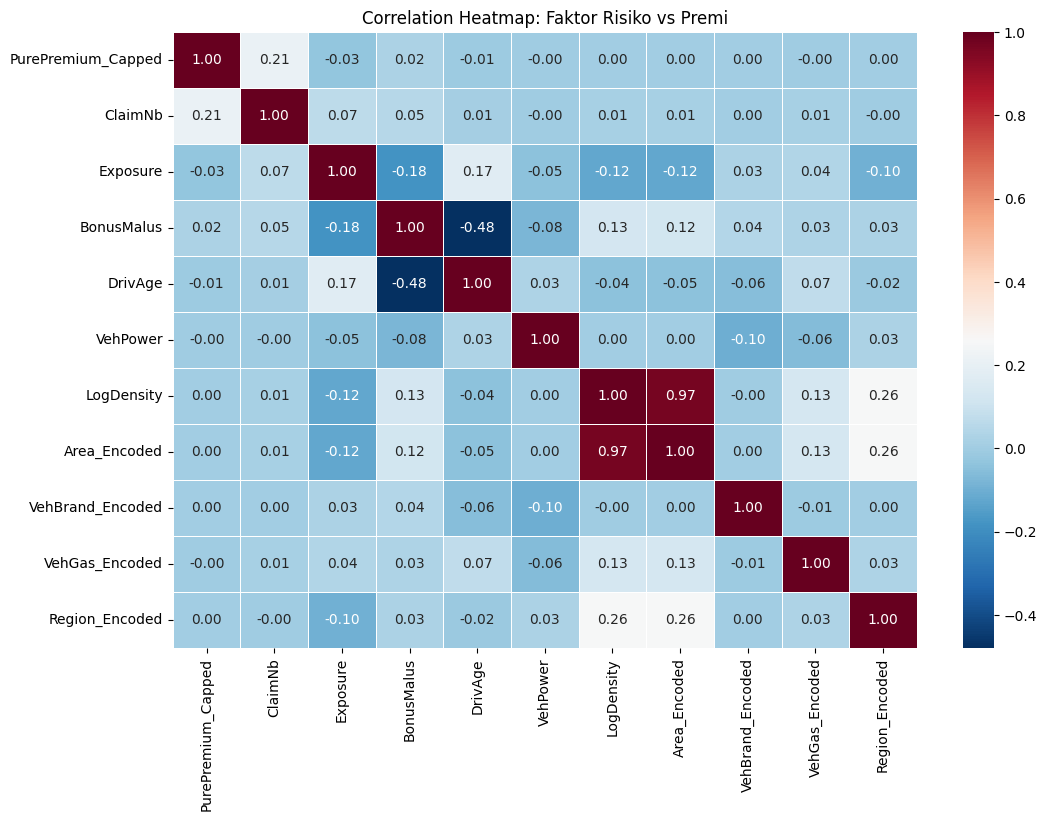

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_final[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Faktor Risiko vs Premi')
plt.savefig('correlation_heatmap.png')
# Catatan: Perhatikan korelasi BonusMalus dengan PurePremium_Capped, biasanya ini yang terkuat.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

3. Kode Distribution Plot Kita akan melihat bagaimana profil risiko berubah berdasarkan usia pengemudi (DrivAge) dan tingkat BonusMalus.

/tmp/ipython-input-1471606810.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_premium = df_final.groupby('DrivAge_Bin')['PurePremium_Capped'].mean().reset_index()
/tmp/ipython-input-1471606810.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_premium, x='DrivAge_Bin', y='PurePremium_Capped', palette='viridis', ax=ax2)


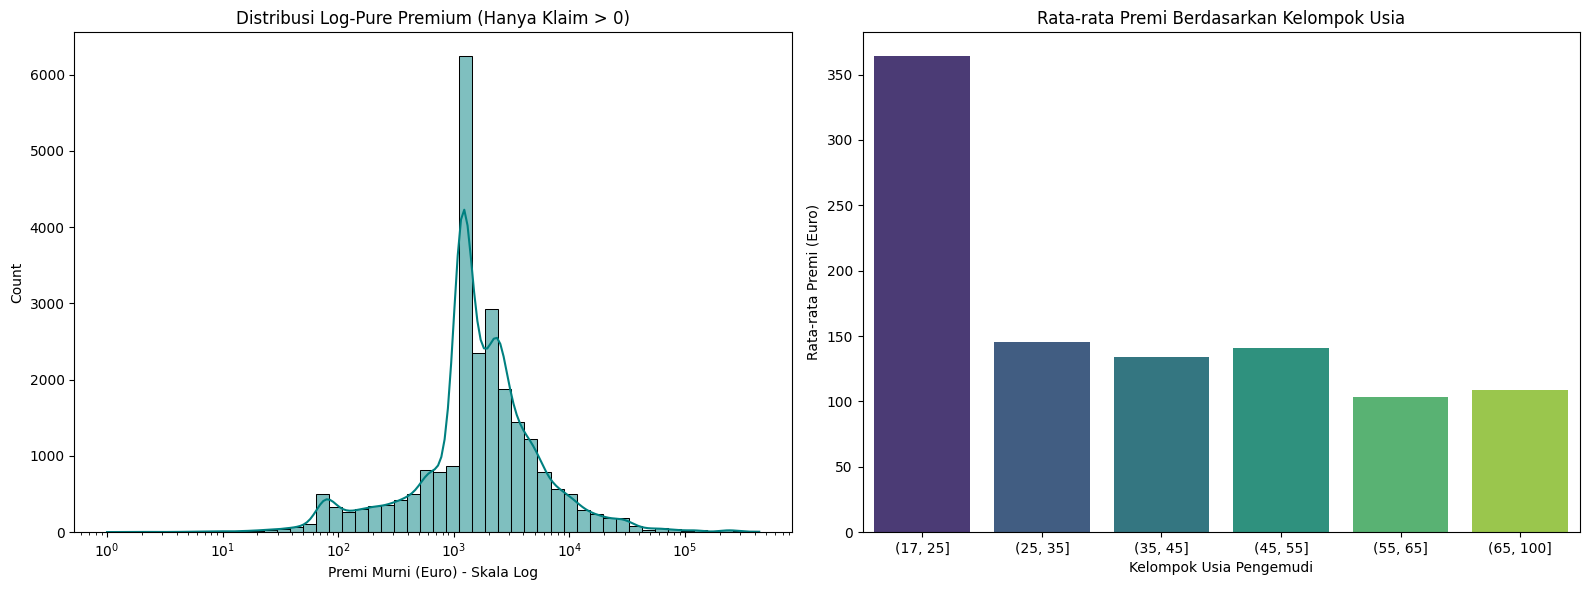

In [ ]:
# Membuat subplot 1x2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribusi Pure Premium (Log Scale karena data sangat skewed)
# Kita hanya melihat data yang PurePremium > 0 agar log-nya valid
sns.histplot(df_final[df_final['PurePremium_Capped'] > 0]['PurePremium_Capped'],
             bins=50, kde=True, ax=ax1, log_scale=True, color='teal')
ax1.set_title('Distribusi Log-Pure Premium (Hanya Klaim > 0)')
ax1.set_xlabel('Premi Murni (Euro) - Skala Log')

# Plot 2: Hubungan Usia Pengemudi dengan Rata-rata Premi
# Kita bagi usia menjadi kelompok (binning) untuk melihat tren
df_final['DrivAge_Bin'] = pd.cut(df_final['DrivAge'], bins=[17, 25, 35, 45, 55, 65, 100])
age_premium = df_final.groupby('DrivAge_Bin')['PurePremium_Capped'].mean().reset_index()

sns.barplot(data=age_premium, x='DrivAge_Bin', y='PurePremium_Capped', palette='viridis', ax=ax2)
ax2.set_title('Rata-rata Premi Berdasarkan Kelompok Usia')
ax2.set_xlabel('Kelompok Usia Pengemudi')
ax2.set_ylabel('Rata-rata Premi (Euro)')

plt.tight_layout()
plt.savefig('distribution_analysis.png')

Penjelasan Visualisasi

**Correlation Heatmap:**

  Apa yang dicari? Cari variabel yang memiliki angka korelasi positif tinggi dengan PurePremium_Capped. Biasanya, BonusMalus akan memiliki korelasi positif (semakin tinggi skor malus, semakin tinggi premi).

  Interaksi: Periksa korelasi antara LogDensity dan Area_Encoded. Jika korelasinya sangat tinggi (di atas 0.8), ini disebut multicollinearity, yang perlu diperhatikan saat membuat model GLM.

**Log-Pure Premium Distribution:**

  Grafik ini menunjukkan "Ekor Panjang" (Long Tail) dari risiko asuransi. Meskipun sudah di-capping, Anda akan melihat bahwa sebagian besar klaim berada di nilai tertentu, namun masih ada variasi yang lebar. Ini adalah bukti visual mengapa kita butuh distribusi Tweedie atau Gamma.

**Rata-rata Premi per Usia:**

  Tren "U-Shape": Biasanya Anda akan melihat premi sangat tinggi untuk pengemudi muda (18-25), kemudian turun dan stabil, lalu mulai naik lagi sedikit saat pengemudi mencapai usia lansia. Visualisasi ini membuktikan bahwa variabel DrivAge memiliki hubungan non-linear terhadap risiko.

**Kesimpulan :**

  "Visualisasi korelasi menunjukkan bahwa BonusMalus adalah prediktor terkuat untuk besaran premi. Selain itu, analisis kelompok usia mengonfirmasi adanya risiko tinggi pada pengemudi muda, yang memvalidasi keputusan untuk menggunakan model non-linear seperti Gradient Boosting untuk menangkap pola ini secara lebih akurat dibanding model linear standar."